In [1]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd

os.makedirs("/workspace/outputs/figures", exist_ok=True)

with open("/workspace/outputs/metrics/als_metrics.json", "r", encoding="utf-8") as f:
    als_metrics = json.load(f)

with open("/workspace/outputs/metrics/ncf_metrics.json", "r", encoding="utf-8") as f:
    ncf_metrics = json.load(f)

als_metrics, ncf_metrics

({'model': 'Spark ALS',
  'rank': 32,
  'maxIter': 8,
  'regParam': 0.08,
  'rmse': 0.778016972618774,
  'mae': 0.6041632994208022},
 {'model': 'Neural Collaborative Filtering',
  'embedding_dim': 64,
  'batch_size': 8192,
  'accuracy': 0.9293653964996338,
  'auc': 0.9725552797317505,
  'loss': 0.20964539051055908})

In [2]:
import json
import math
import numpy as np
import pandas as pd

comparison = pd.DataFrame([
    {
        "model": "Spark ALS",
        "task": "Rating prediction / Candidate recommendation",
        "main_metric": "RMSE/MAE",
        "rmse": als_metrics.get("rmse"),
        "mae": als_metrics.get("mae"),
        "loss": None,
        "accuracy": None,
        "auc": None
    },
    {
        "model": "TensorFlow NCF",
        "task": "Binary preference prediction / Re-ranking",
        "main_metric": "Loss/Accuracy/AUC",
        "rmse": None,
        "mae": None,
        "loss": ncf_metrics.get("loss"),
        "accuracy": ncf_metrics.get("accuracy"),
        "auc": ncf_metrics.get("auc")
    }
])

comparison_display = comparison.fillna("Không áp dụng")
comparison_display

,model,task,main_metric,rmse,mae,loss,accuracy,auc
0,Spark ALS,Rating prediction / Candidate recommendation,RMSE/MAE,0.778017,0.604163,Không áp dụng,Không áp dụng,Không áp dụng
1,TensorFlow NCF,Binary preference prediction / Re-ranking,Loss/Accuracy/AUC,Không áp dụng,Không áp dụng,0.209645,0.929365,0.972555


In [3]:
def clean_for_json(obj):
    if isinstance(obj, dict):
        return {k: clean_for_json(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [clean_for_json(v) for v in obj]

    if isinstance(obj, tuple):
        return [clean_for_json(v) for v in obj]

    if isinstance(obj, (np.integer,)):
        return int(obj)

    if isinstance(obj, (np.floating, float)):
        value = float(obj)
        if math.isnan(value) or math.isinf(value):
            return None
        return value

    if isinstance(obj, (np.bool_,)):
        return bool(obj)

    return obj


comparison.to_csv("/workspace/outputs/metrics/model_comparison.csv", index=False)

comparison_records = clean_for_json(comparison.to_dict(orient="records"))

with open("/workspace/outputs/metrics/model_comparison.json", "w", encoding="utf-8") as f:
    json.dump(
        comparison_records,
        f,
        ensure_ascii=False,
        indent=2,
        allow_nan=False
    )

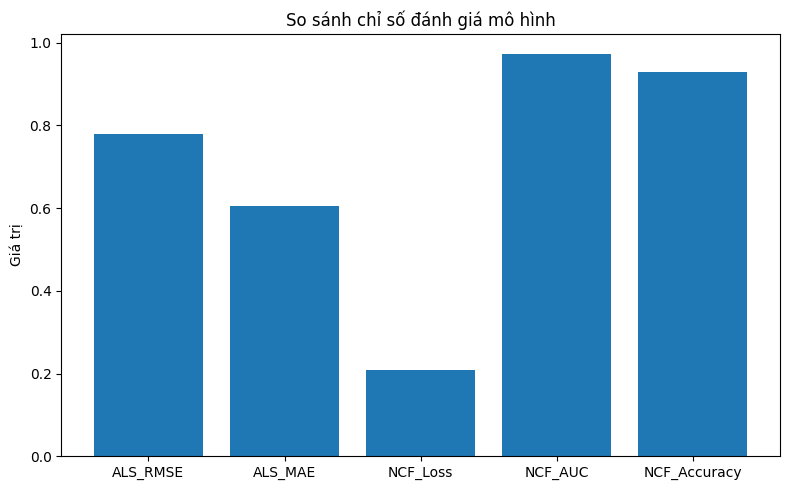

In [4]:
plot_df = pd.DataFrame([
    {"metric": "ALS_RMSE", "value": als_metrics.get("rmse")},
    {"metric": "ALS_MAE", "value": als_metrics.get("mae")},
    {"metric": "NCF_Loss", "value": ncf_metrics.get("loss")},
    {"metric": "NCF_AUC", "value": ncf_metrics.get("auc")},
    {"metric": "NCF_Accuracy", "value": ncf_metrics.get("accuracy")},
]).dropna()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["metric"], plot_df["value"])
plt.ylabel("Giá trị")
plt.title("So sánh chỉ số đánh giá mô hình")
plt.tight_layout()
plt.savefig("/workspace/outputs/figures/model_comparison.png", dpi=200)
plt.show()